In [1]:
!pip install -q pandas numpy matplotlib seaborn folium requests

import os
import io
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

sns.set_theme(style="whitegrid")

DATA_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

response = requests.get(DATA_URL, timeout=60)
response.raise_for_status()

df = pd.read_csv(io.BytesIO(response.content))

df["Date"] = pd.to_datetime(df["Date"])

print("Data loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Data loaded successfully!
Shape: (528, 15)

Columns:
['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence', 'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition', 'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales', 'Vehicle_Type', 'City']


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,1980-02-29,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,1980-03-31,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,1980-04-30,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,1980-05-31,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


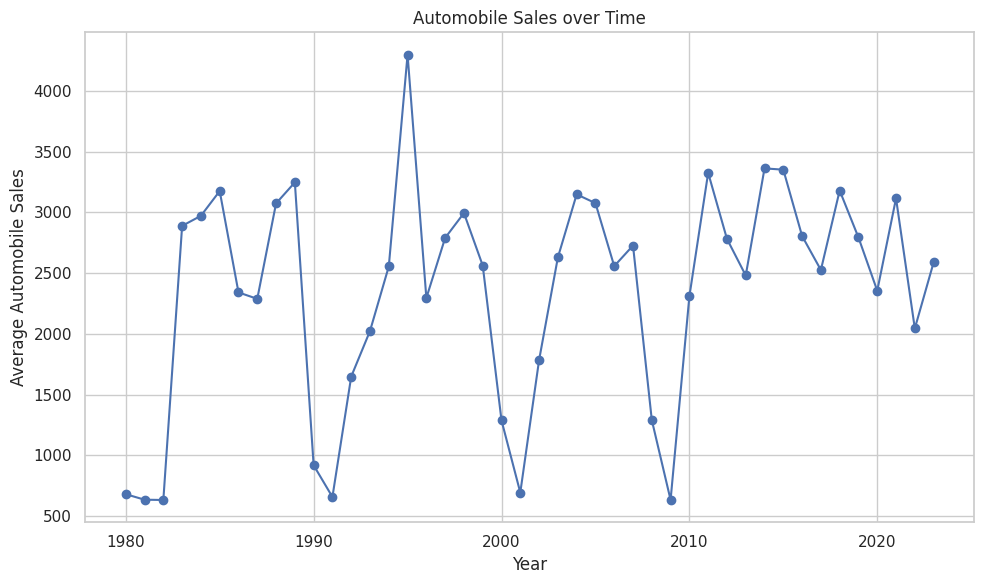

In [2]:
yearly_sales = df.groupby("Year")["Automobile_Sales"].mean()

plt.figure(figsize=(10, 6))

yearly_sales.plot(
    kind="line",
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Automobile Sales")
plt.title("Automobile Sales over Time")

plt.tight_layout()
plt.show()

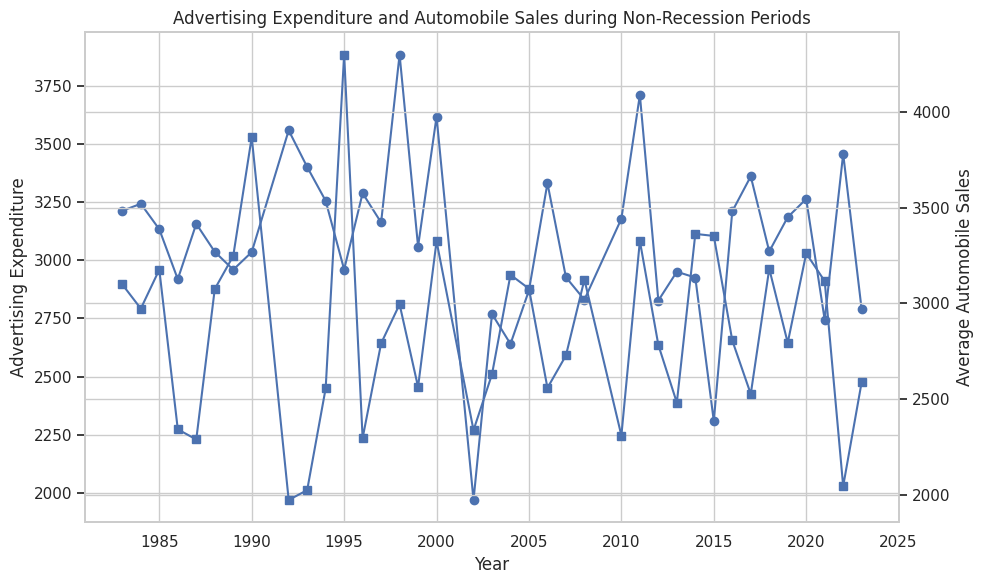

In [3]:
non_recession = df[df["Recession"] == 0]

ad_sales = non_recession.groupby(
    "Year",
    as_index=False
)[
    ["Advertising_Expenditure", "Automobile_Sales"]
].mean()

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(
    ad_sales["Year"],
    ad_sales["Advertising_Expenditure"],
    marker="o",
    label="Advertising Expenditure"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Advertising Expenditure")

ax2 = ax1.twinx()

ax2.plot(
    ad_sales["Year"],
    ad_sales["Automobile_Sales"],
    marker="s",
    label="Automobile Sales"
)

ax2.set_ylabel("Average Automobile Sales")

plt.title(
    "Advertising Expenditure and Automobile Sales during Non-Recession Periods"
)

fig.tight_layout()
plt.show()


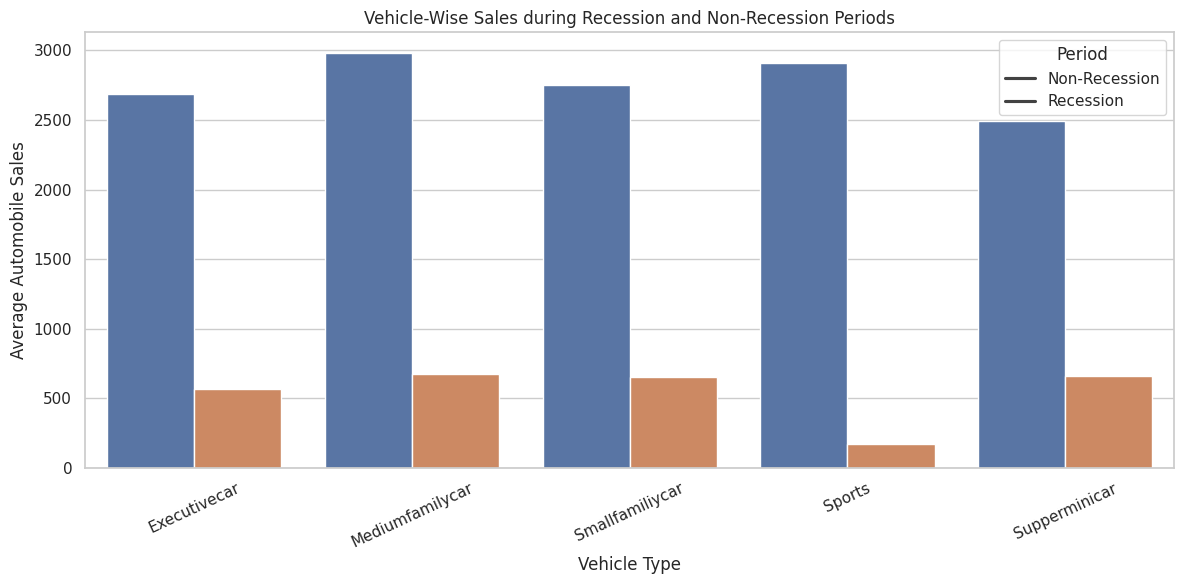

In [4]:
vehicle_period = df.groupby(
    ["Recession", "Vehicle_Type"],
    as_index=False
)["Automobile_Sales"].mean()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=vehicle_period,
    x="Vehicle_Type",
    y="Automobile_Sales",
    hue="Recession"
)

plt.xlabel("Vehicle Type")
plt.ylabel("Average Automobile Sales")
plt.title(
    "Vehicle-Wise Sales during Recession and Non-Recession Periods"
)

plt.xticks(rotation=25)

plt.legend(
    title="Period",
    labels=["Non-Recession", "Recession"]
)

plt.tight_layout()
plt.show()

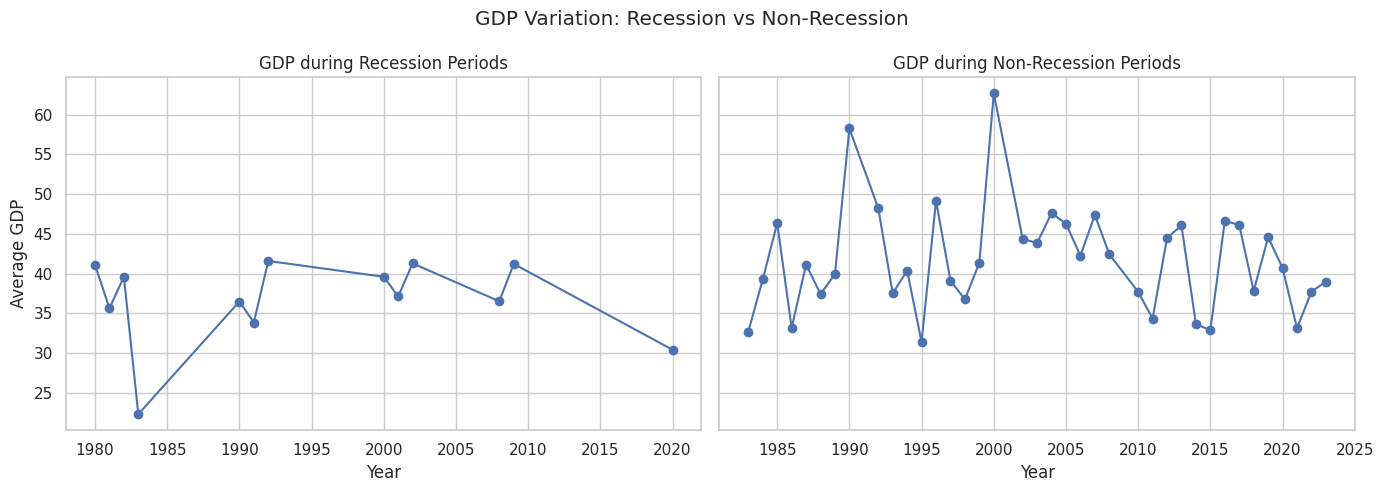

In [5]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    sharey=True
)

recession_gdp = df[
    df["Recession"] == 1
].groupby("Year")["GDP"].mean()

non_recession_gdp = df[
    df["Recession"] == 0
].groupby("Year")["GDP"].mean()

# Recession
axes[0].plot(
    recession_gdp.index,
    recession_gdp.values,
    marker="o"
)

axes[0].set_title("GDP during Recession Periods")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average GDP")

# Non-Recession
axes[1].plot(
    non_recession_gdp.index,
    non_recession_gdp.values,
    marker="o"
)

axes[1].set_title("GDP during Non-Recession Periods")
axes[1].set_xlabel("Year")

plt.suptitle(
    "GDP Variation: Recession vs Non-Recession"
)

plt.tight_layout()
plt.show()

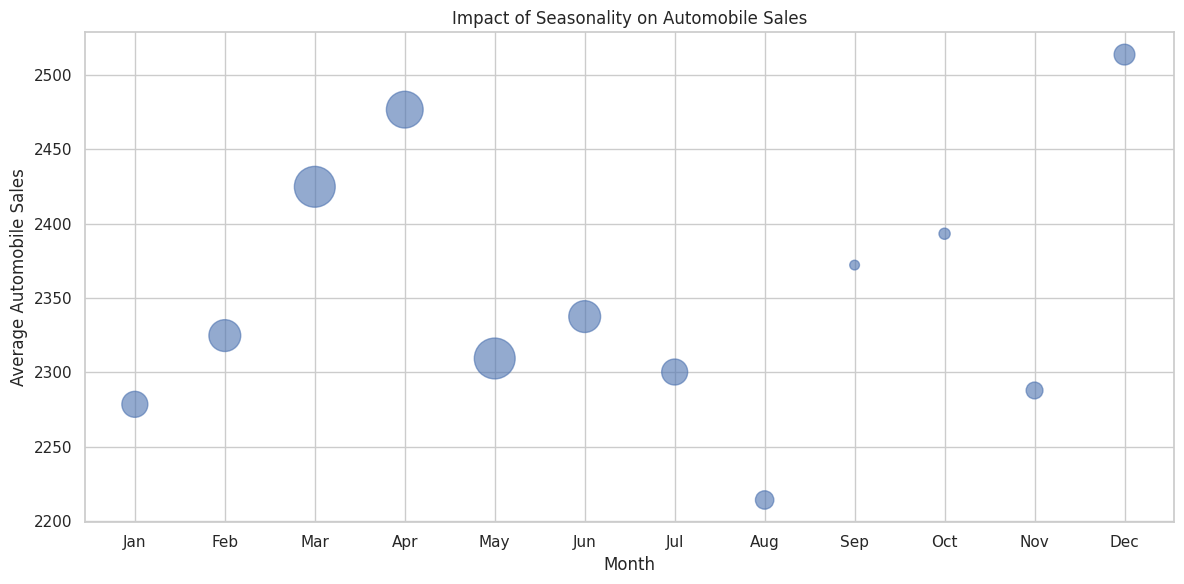

In [6]:
seasonality = df.groupby(
    "Month",
    as_index=False
).agg(
    Automobile_Sales=("Automobile_Sales", "mean"),
    Seasonality_Weight=("Seasonality_Weight", "mean")
)

month_order = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

seasonality["Month"] = pd.Categorical(
    seasonality["Month"],
    categories=month_order,
    ordered=True
)

seasonality = seasonality.sort_values("Month")

plt.figure(figsize=(12, 6))

plt.scatter(
    seasonality["Month"],
    seasonality["Automobile_Sales"],
    s=seasonality["Seasonality_Weight"].clip(lower=0.05) * 700,
    alpha=0.6
)

plt.xlabel("Month")
plt.ylabel("Average Automobile Sales")
plt.title("Impact of Seasonality on Automobile Sales")

plt.tight_layout()
plt.show()

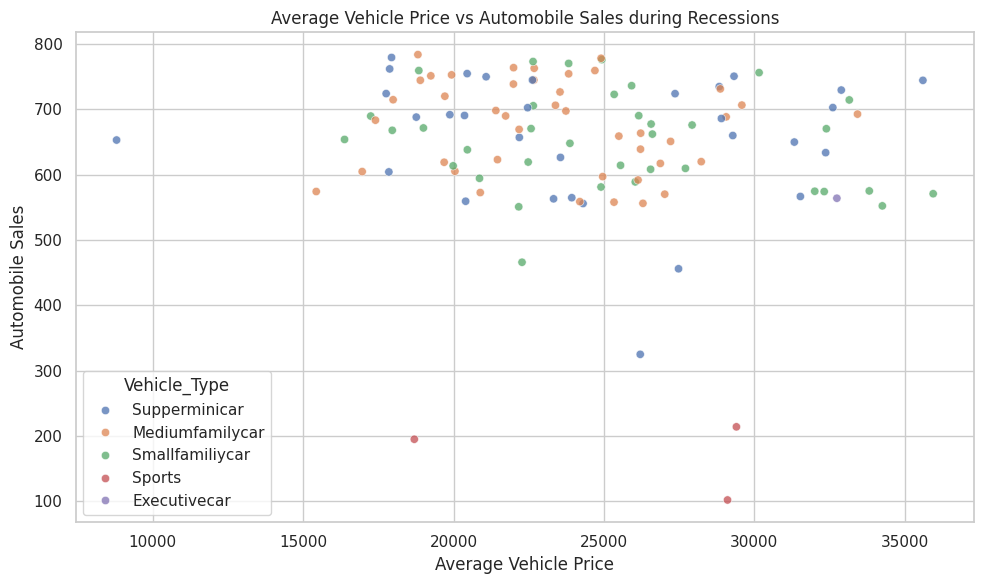

In [7]:
recession_data = df[df["Recession"] == 1]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=recession_data,
    x="Price",
    y="Automobile_Sales",
    hue="Vehicle_Type",
    alpha=0.75
)

plt.xlabel("Average Vehicle Price")
plt.ylabel("Automobile Sales")

plt.title(
    "Average Vehicle Price vs Automobile Sales during Recessions"
)

plt.tight_layout()
plt.show()

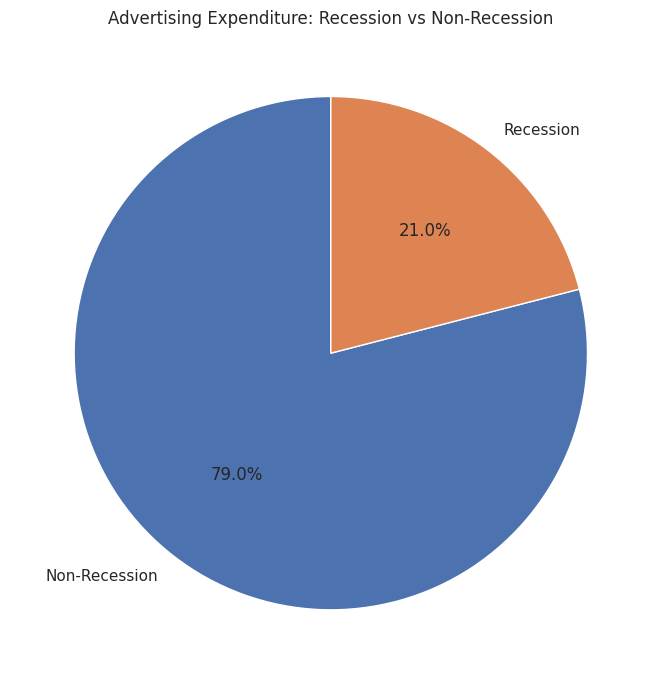

In [8]:
ad_period = df.groupby(
    "Recession"
)["Advertising_Expenditure"].sum()

plt.figure(figsize=(7, 7))

plt.pie(
    ad_period.values,
    labels=["Non-Recession", "Recession"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Advertising Expenditure: Recession vs Non-Recession"
)

plt.tight_layout()
plt.show()

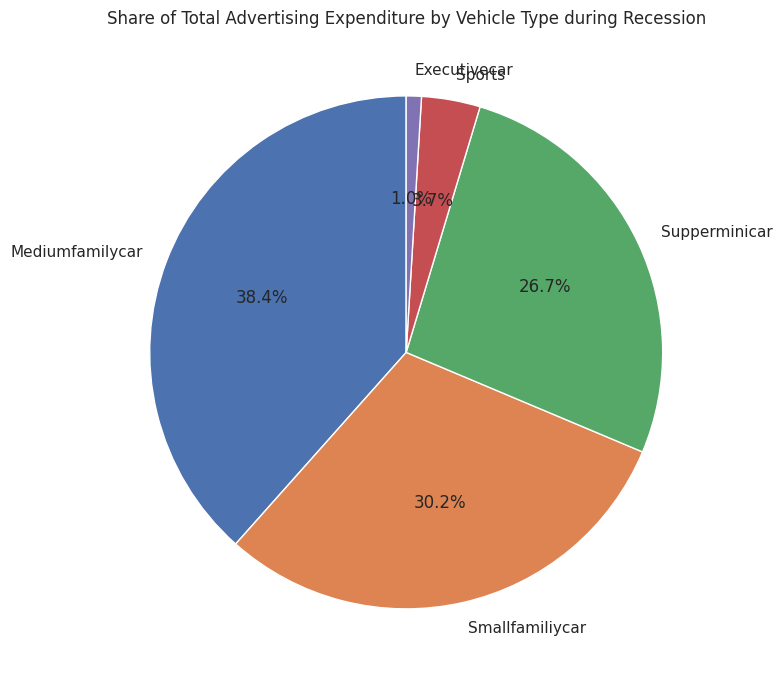

In [9]:
vehicle_ad = recession_data.groupby(
    "Vehicle_Type"
)["Advertising_Expenditure"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(8, 8))

plt.pie(
    vehicle_ad.values,
    labels=vehicle_ad.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Share of Total Advertising Expenditure by Vehicle Type during Recession"
)

plt.tight_layout()
plt.show()

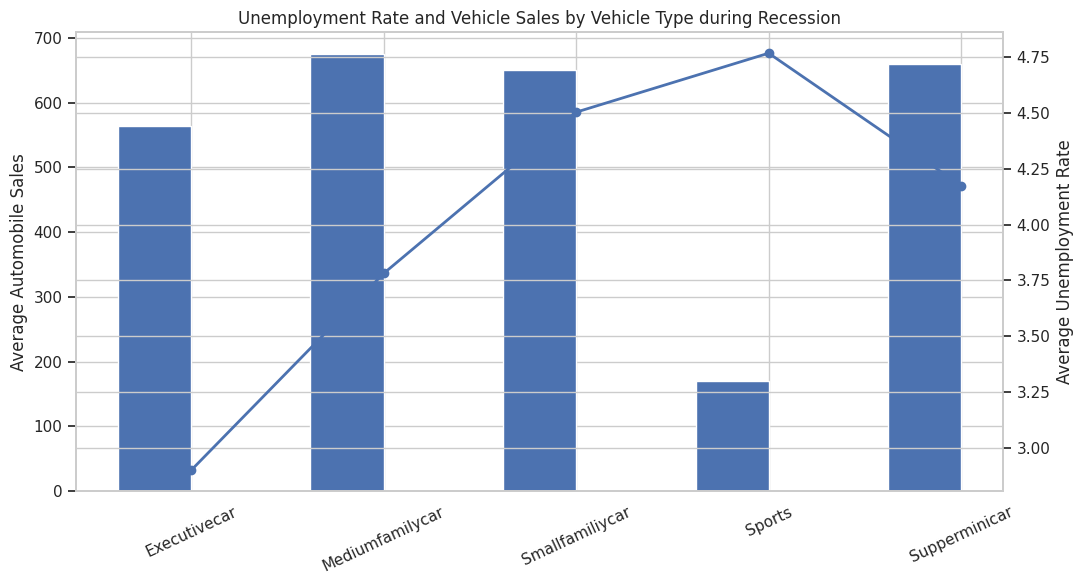

In [10]:
unemployment_vehicle = recession_data.groupby(
    "Vehicle_Type",
    as_index=False
).agg(
    unemployment_rate=("unemployment_rate", "mean"),
    Automobile_Sales=("Automobile_Sales", "mean")
)

fig, ax1 = plt.subplots(figsize=(11, 6))

x = np.arange(len(unemployment_vehicle))
width = 0.38

# Automobile Sales
ax1.bar(
    x - width / 2,
    unemployment_vehicle["Automobile_Sales"],
    width,
    label="Average Sales"
)

ax1.set_ylabel("Average Automobile Sales")

ax1.set_xticks(x)

ax1.set_xticklabels(
    unemployment_vehicle["Vehicle_Type"],
    rotation=25
)

# Unemployment Rate
ax2 = ax1.twinx()

ax2.plot(
    x,
    unemployment_vehicle["unemployment_rate"],
    marker="o",
    linewidth=2,
    label="Unemployment Rate"
)

ax2.set_ylabel("Average Unemployment Rate")

plt.title(
    "Unemployment Rate and Vehicle Sales by Vehicle Type during Recession"
)

fig.tight_layout()
plt.show()